# CNN-1

> Знакомимся со сверточными нейронными сетями.  
> Решаем задачу классификации изображений

some materials inspired by [course](http://wiki.cs.hse.ru/%D0%93%D0%BB%D1%83%D0%B1%D0%B8%D0%BD%D0%BD%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_1_24/25)


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import FashionMNIST
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rc('font', size=10)

## Opencv
Библиотека для удобной работы с картинками

## Загрузка изображения

Загрузим изображение из интернета, например, мем про юккури. :)

In [ ]:
! wget "https://static.wikia.nocookie.net/yukkuri/images/f/fc/Take_It_Easy!.jpg" -O yukkuri.jpg

: 

## Чтение изображения

In [ ]:
img = Image.open('yukkuri.jpg')
print(img.format)
print(img.size)
print(img.mode)

WEBP
(600, 334)
RGB


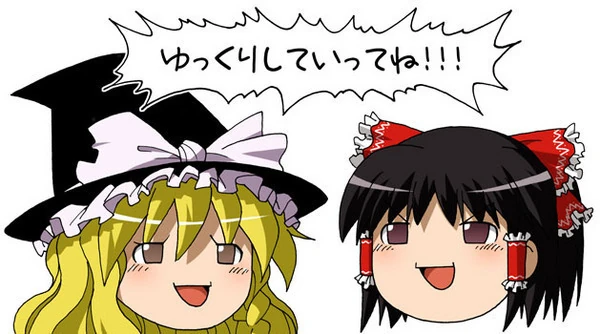

In [ ]:
img

## Матричное представление

In [ ]:
img_matrix = np.array(img)
img_matrix.shape

(334, 600, 3)

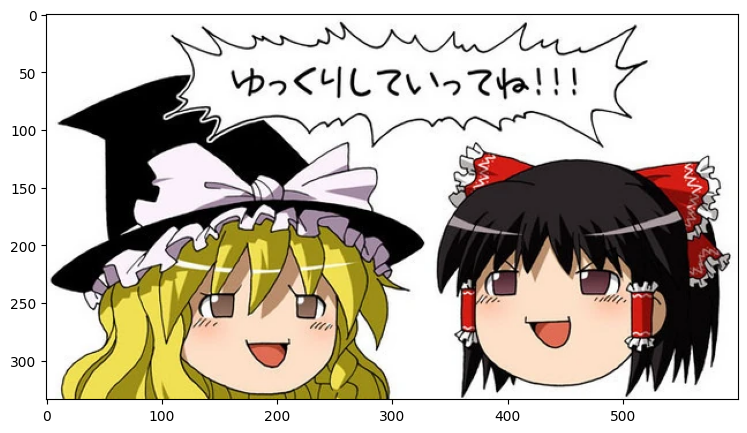

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(img_matrix)
plt.show()

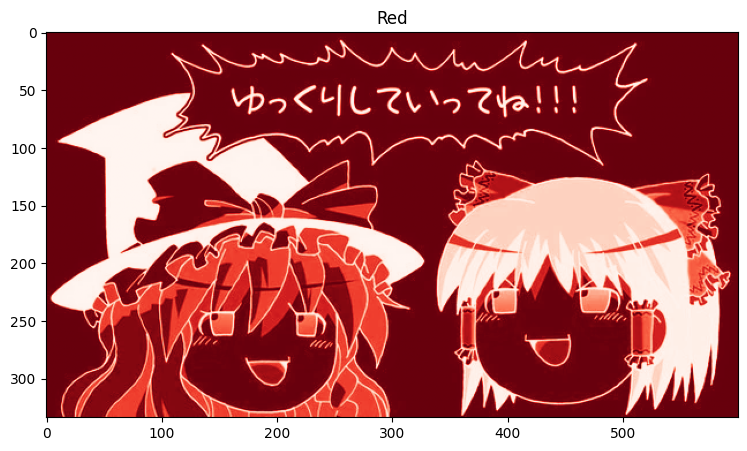

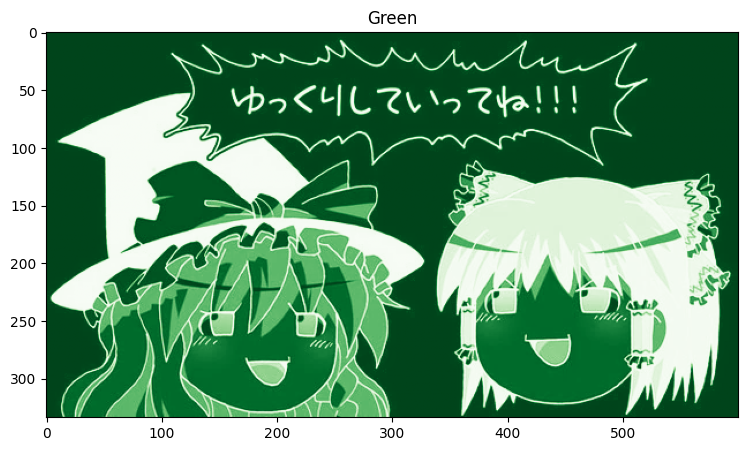

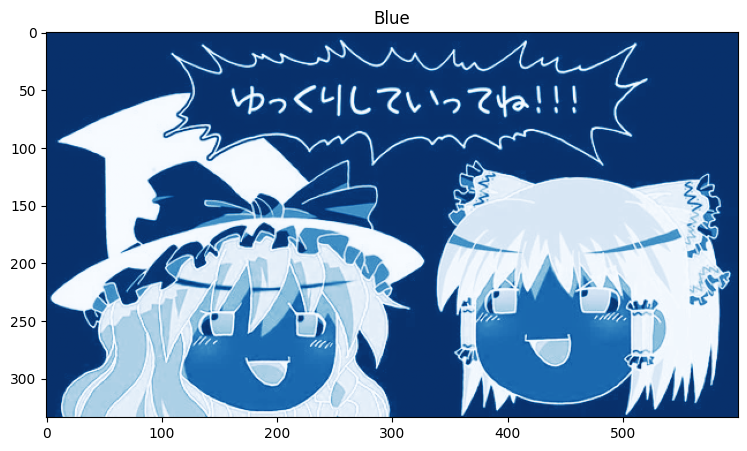

In [ ]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(10, 5))
    plt.imshow(img_matrix[:, :, i], cmap=cmap)
    plt.title(color)
    plt.show()

In [ ]:
img_matrix[:, :, 0].min(), img_matrix[:, :, 0].max()

(np.uint8(0), np.uint8(255))

## Примеры простых фильтров

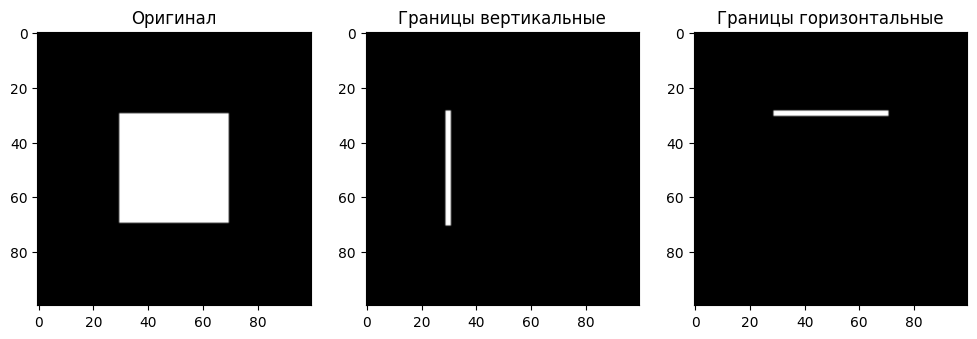

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = np.zeros((100, 100), dtype=np.uint8)
img[30:70, 30:70] = 255

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

edges = cv2.filter2D(img, -1, sobel_x)
blurred = cv2.filter2D(img, -1, sobel_y)

plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(img, cmap='gray'); plt.title('Оригинал')
plt.subplot(132); plt.imshow(np.abs(edges), cmap='gray'); plt.title('Границы вертикальные')
plt.subplot(133); plt.imshow(blurred, cmap='gray'); plt.title('Границы горизонтальные')
plt.show()

## Свертка

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True


> Так же есть реализация свертки в модуле `nn.fuctional.conv2d`

In [ ]:
import torch.nn.functional as F


img_gray = Image.open('yukkuri.jpg').convert('L')  # Convert to grayscale
img_tensor = torch.tensor(np.array(img_gray), dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

# Define Sobel kernels (use torch tensor)
# YOUR CODE THERE
sobel_x = ...
sobel_y = ...

edges_x = F.conv2d(img_tensor, sobel_x, padding=1)
edges_y = F.conv2d(img_tensor, sobel_y, padding=1)


plt.figure(figsize=(12, 4))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(132), plt.imshow(edges_x.squeeze().numpy(), cmap='gray'), plt.title('Sobel X'), plt.axis('off')
plt.subplot(133), plt.imshow(edges_y.squeeze().numpy(), cmap='gray'), plt.title('Sobel Y'), plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
)

In [ ]:
conv1.weight.shape

torch.Size([10, 3, 3, 3])

In [ ]:
img_tensor = T.ToTensor()(img).unsqueeze(0)
img_tensor.shape

torch.Size([1, 3, 334, 600])

In [ ]:
output = conv1(img_tensor)

In [ ]:
output.shape

torch.Size([1, 10, 332, 598])

In [ ]:
conv2 = nn.Conv2d(
    in_channels=10,
    out_channels=10,
    kernel_size=3,
    padding=1
)

In [ ]:
output = conv2(output)

In [ ]:
output.shape

torch.Size([1, 10, 332, 598])

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [ ]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [ ]:
img_tensor

tensor([[[0., 0., 1., 4., 4., 5., 5., 2., 9., 3.],
         [7., 8., 8., 4., 2., 7., 7., 8., 9., 0.],
         [0., 2., 8., 7., 0., 4., 1., 7., 4., 6.],
         [3., 9., 1., 4., 8., 8., 9., 3., 4., 7.],
         [2., 3., 4., 1., 4., 2., 9., 4., 1., 6.],
         [0., 5., 1., 2., 2., 8., 8., 5., 7., 8.],
         [0., 3., 4., 1., 9., 6., 0., 9., 7., 8.],
         [1., 0., 3., 6., 4., 4., 3., 4., 2., 9.],
         [9., 1., 3., 9., 8., 0., 3., 3., 5., 9.],
         [1., 1., 2., 5., 5., 6., 7., 0., 7., 5.]]])

In [ ]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [ ]:
pooling1(img_tensor)

tensor([[[8., 8., 7., 8., 9.],
         [9., 8., 8., 9., 7.],
         [5., 4., 8., 9., 8.],
         [3., 6., 9., 9., 9.],
         [9., 9., 8., 7., 9.]]])

In [ ]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [ ]:
pooling2(img_tensor)

tensor([[[3.7500, 4.2500, 4.5000, 5.5000, 5.2500],
         [3.5000, 5.0000, 5.0000, 5.0000, 5.2500],
         [2.5000, 2.0000, 4.0000, 6.5000, 5.5000],
         [1.0000, 3.5000, 5.7500, 4.0000, 6.5000],
         [3.0000, 4.7500, 4.7500, 3.2500, 6.5000]]])

## Датасет FashionMNIST

In [ ]:
fashion_mnist = FashionMNIST(
    "../../datasets/fashionmnist",
    train=False,
    download=True
    )
print(fashion_mnist.data.shape)
print(type(fashion_mnist[0][0]))
fashion_mnist[0][0]

torch.Size([10000, 28, 28])
<class 'PIL.Image.Image'>


> Загрузим датасет сразу в формате `torch.tensor`

In [ ]:
from torch.utils.data import Dataset, DataLoader

train_set = FashionMNIST('.FashionMNIST', transform=T.ToTensor(), train=True, download=True)
val_set = FashionMNIST('.FashionMNIST', transform=T.ToTensor(), train=False, download=True)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.22MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 56.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.3MB/s]


In [ ]:
train_set

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: .FashionMNIST
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
x, y = train_set[0]
x.shape

torch.Size([1, 28, 28])

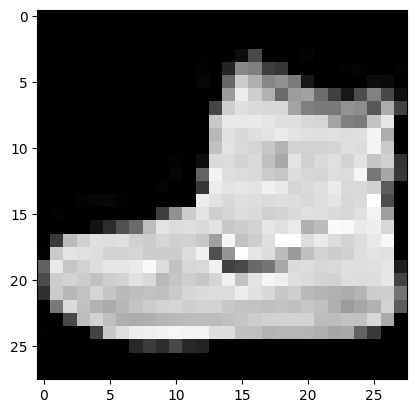

Class:  9


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x[0,:,:], cmap='gray')
plt.show()
print("Class: ", y)

In [ ]:
x.shape

torch.Size([1, 28, 28])

## Полносвязная нейронная сеть

Обучим полносвязную нейронную сеть на датасете FashionMNIST

In [ ]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

In [ ]:
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        # YOUR CODE HERE


    def forward(self, x): # (batch_size, 1, 28, 28)
        # YOUR CODE HERE


        x = ...

        return x

In [ ]:
batch = next(iter(train_loader))
print(batch[1].shape)

net = MLP(hidden_size=100)
print(net(batch[0]).shape)

Посчитаем количество обучаемых параметров

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(net)

79510

In [ ]:
def test(net, loader):
    net.eval()

    correct, total = 0, 0

    for batch in loader:
        images, labels = batch[0], batch[1]
        images = images.to('cuda')
        labels = labels.to('cuda')

        with torch.no_grad():
            out = net(images)
        pred = torch.argmax(out, dim=1)

        total += len(pred)
        correct += (pred == labels).cpu().numpy().sum()

    return correct / total

In [ ]:
def train(net, train_loader, val_loader, optimizer, epochs=10):
    train_acc, val_acc = [], []
    net.train()

    for epoch in range(epochs):

        correct, total = 0, 0

        for batch in train_loader:
            images, labels = batch[0], batch[1]
            images = images.to('cuda')
            labels = labels.to('cuda')

            optimizer.zero_grad()
            out = net(images)

            # YOUR CODE HERE
            loss = ...
            loss.backward()
            optimizer.step()

            # YOUR CODE HERE
            pred = ...

            total += len(pred)
            correct += (pred == labels).detach().cpu().numpy().sum()

        train_acc.append(correct / total)
        val_acc.append(test(net, val_loader))

        print(f"Epoch: {epoch}")
        print(f"train accuracy: {train_acc[-1]}")
        print(f"val accuracy: {val_acc[-1]}")

    return train_acc, val_acc

In [ ]:
net = MLP(hidden_size=1000).to('cuda')
optimizer = torch.optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

In [ ]:
train_acc, val_acc = train(net, train_loader, val_loader, optimizer, epochs=5)

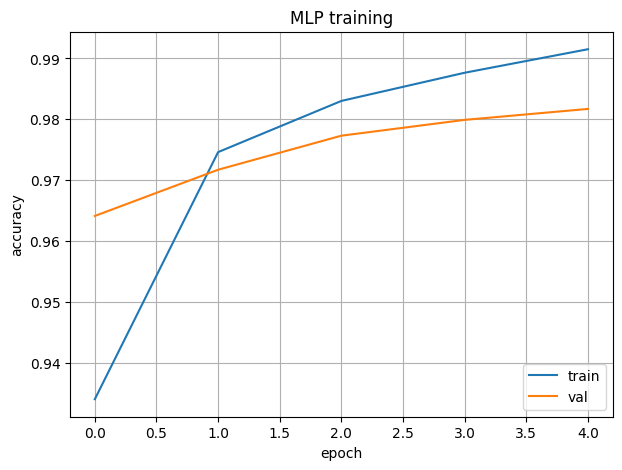

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(np.arange(5), train_acc, label='train')
plt.plot(np.arange(5), val_acc, label='val')

plt.grid()
plt.legend(loc='lower right')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MLP training")
plt.show()

## Сверточная сеть

Теперь обучим сверточную нейронную сеть

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        # YOUR CODE HERE
        self.conv1 = ...
        self.conv2 = ...
        self.pool = ...
        self.fc = ...

    def forward(self, x):
        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))

        x = torch.flatten(x, 1) # flatten
        x = self.fc(x)
        return x

torch.Size([64, 10])

In [ ]:
batch = next(iter(train_loader))
print(batch[1].shape)

conv_net = ConvNet()
print(conv_net(batch[0]).shape)

In [ ]:
count_parameters(net)

18378

In [ ]:
conv_net = ConvNet().to('cuda')
optimizer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.9)
train_acc, val_acc = train(net, train_loader, val_loader, optimizer, epochs=5)

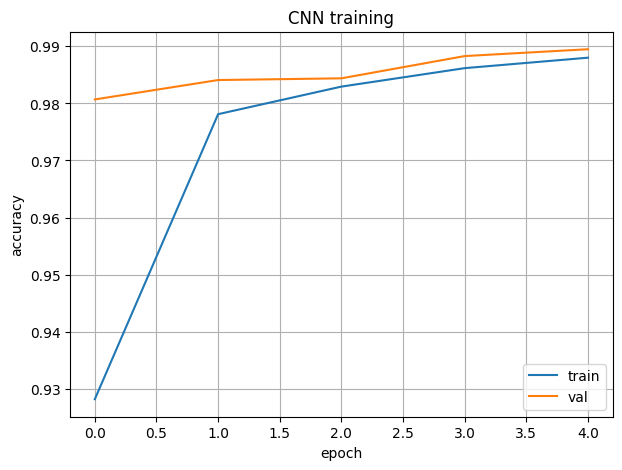

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(np.arange(5), train_acc, label='train')
plt.plot(np.arange(5), val_acc, label='val')
plt.grid()
plt.legend(loc='lower right')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("CNN training")
plt.show()

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import requests
from io import BytesIO



vgg16 = models.vgg16(pretrained=True)
vgg16.eval()  # Set to evaluation mode

print(vgg16)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
total_params = 0
for name, param in vgg16.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(f"{name}: {list(param.shape)} → {num_params:,} parameters")

print(f"\nTotal trainable parameters: {total_params:,}")

features.0.weight: [64, 3, 3, 3] → 1,728 parameters
features.0.bias: [64] → 64 parameters
features.2.weight: [64, 64, 3, 3] → 36,864 parameters
features.2.bias: [64] → 64 parameters
features.5.weight: [128, 64, 3, 3] → 73,728 parameters
features.5.bias: [128] → 128 parameters
features.7.weight: [128, 128, 3, 3] → 147,456 parameters
features.7.bias: [128] → 128 parameters
features.10.weight: [256, 128, 3, 3] → 294,912 parameters
features.10.bias: [256] → 256 parameters
features.12.weight: [256, 256, 3, 3] → 589,824 parameters
features.12.bias: [256] → 256 parameters
features.14.weight: [256, 256, 3, 3] → 589,824 parameters
features.14.bias: [256] → 256 parameters
features.17.weight: [512, 256, 3, 3] → 1,179,648 parameters
features.17.bias: [512] → 512 parameters
features.19.weight: [512, 512, 3, 3] → 2,359,296 parameters
features.19.bias: [512] → 512 parameters
features.21.weight: [512, 512, 3, 3] → 2,359,296 parameters
features.21.bias: [512] → 512 parameters
features.24.weight: [512, 

In [ ]:
def preprocess_image(img):
    preprocess = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return preprocess(img).unsqueeze(0)  # Add batch dimension


def visualize_feature_maps(feature_maps, num_maps=8, title="Feature Maps"):
    """Visualize first few feature maps from a layer"""
    fig, axes = plt.subplots(1, min(num_maps, feature_maps.shape[1]),
                             figsize=(15, 3))
    fig.suptitle(title, fontsize=14)

    for i in range(min(num_maps, feature_maps.shape[1])):
        ax = axes[i] if num_maps > 1 else axes
        fm = feature_maps[0, i].cpu().detach().numpy()
        ax.imshow(fm, cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Filter {i+1}')

    plt.tight_layout()
    plt.show()

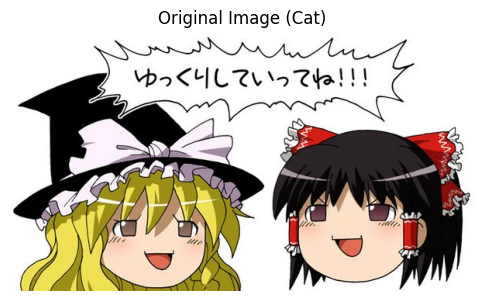


Predicted class: comic book

conv1_1 - Shape: torch.Size([1, 64, 224, 224])


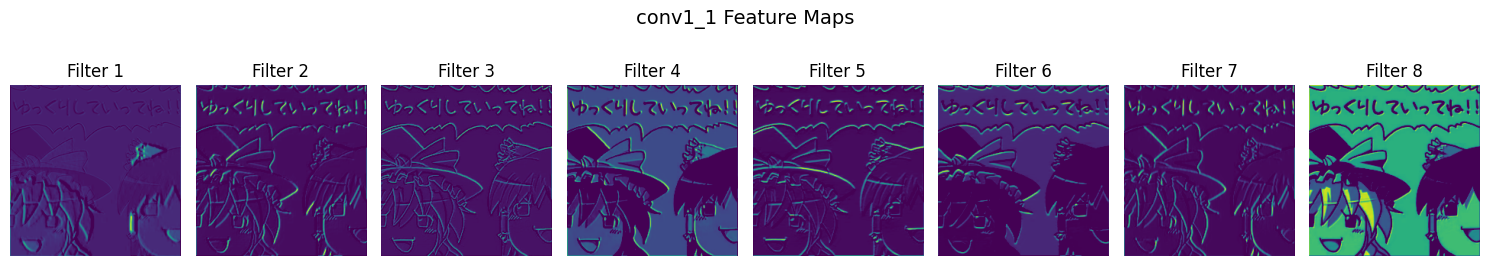


conv2_1 - Shape: torch.Size([1, 128, 112, 112])


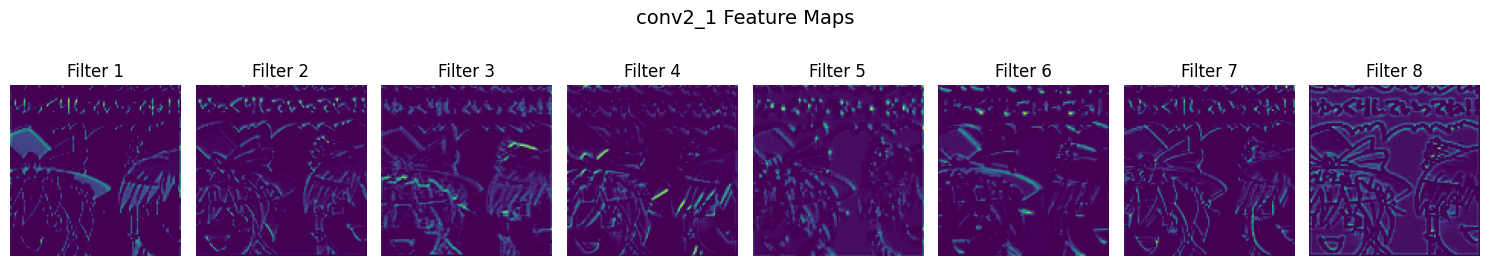


conv3_1 - Shape: torch.Size([1, 256, 56, 56])


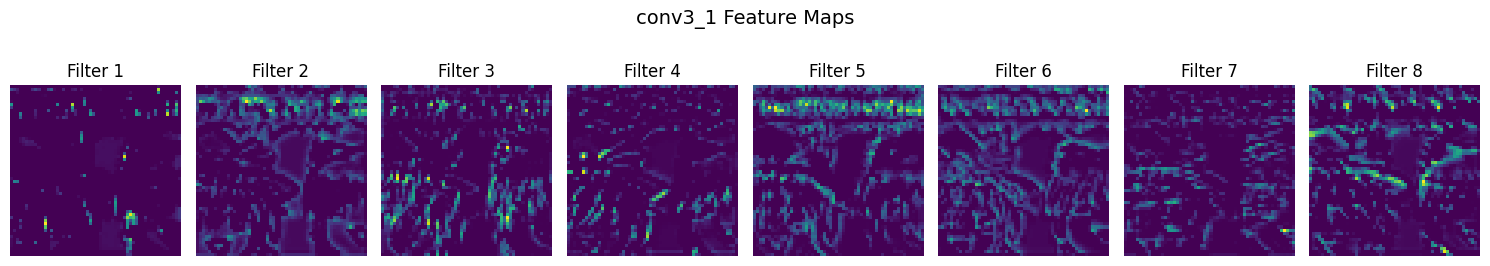


conv4_1 - Shape: torch.Size([1, 512, 28, 28])


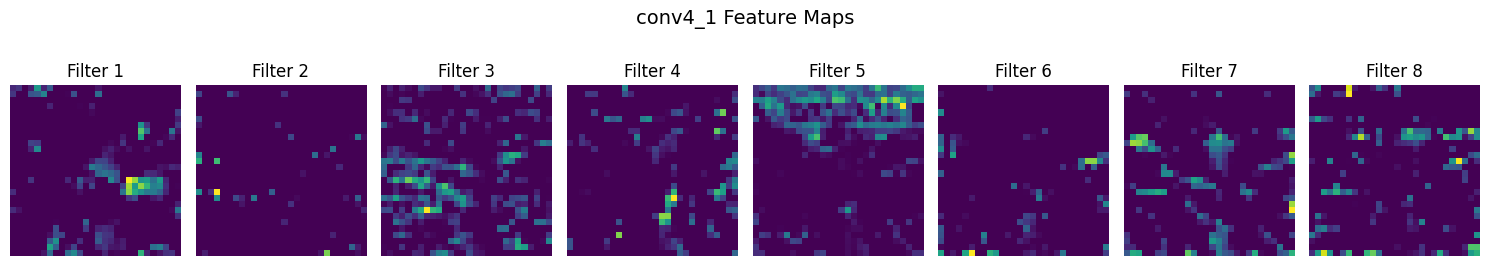


conv5_1 - Shape: torch.Size([1, 512, 14, 14])


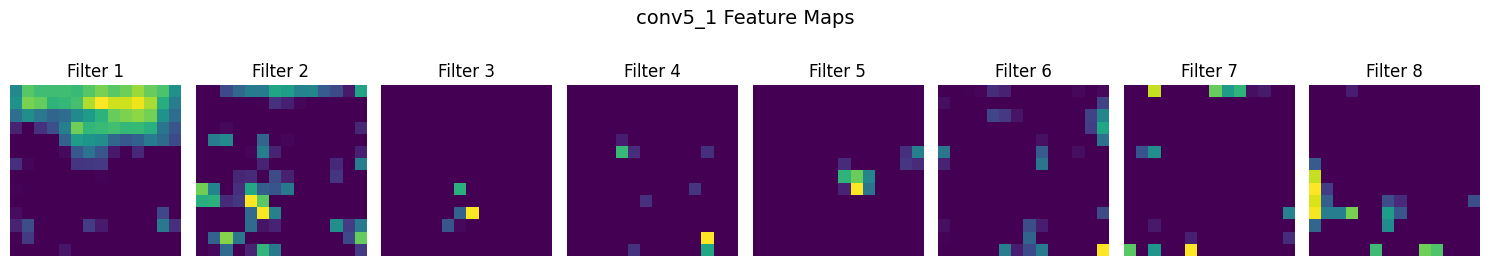

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image (Cat)")
plt.axis('off')
plt.show()

feature_maps = {}

def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

vgg16.features[0].register_forward_hook(get_activation('conv1_1'))   # First conv layer
vgg16.features[5].register_forward_hook(get_activation('conv2_1'))   # After first pooling
vgg16.features[10].register_forward_hook(get_activation('conv3_1'))  # Deeper layer
vgg16.features[17].register_forward_hook(get_activation('conv4_1'))  # Even deeper
vgg16.features[24].register_forward_hook(get_activation('conv5_1'))  # Last conv block

with torch.no_grad():
    output = vgg16(img_tensor)

_, predicted_class = output.max(1)

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
classes = response.text.strip().split('\n')

print(f"\nPredicted class: {classes[predicted_class.item()]}")

for layer_name, fms in feature_maps.items():
    print(f"\n{layer_name} - Shape: {fms.shape}")
    visualize_feature_maps(fms, num_maps=8, title=f"{layer_name} Feature Maps")

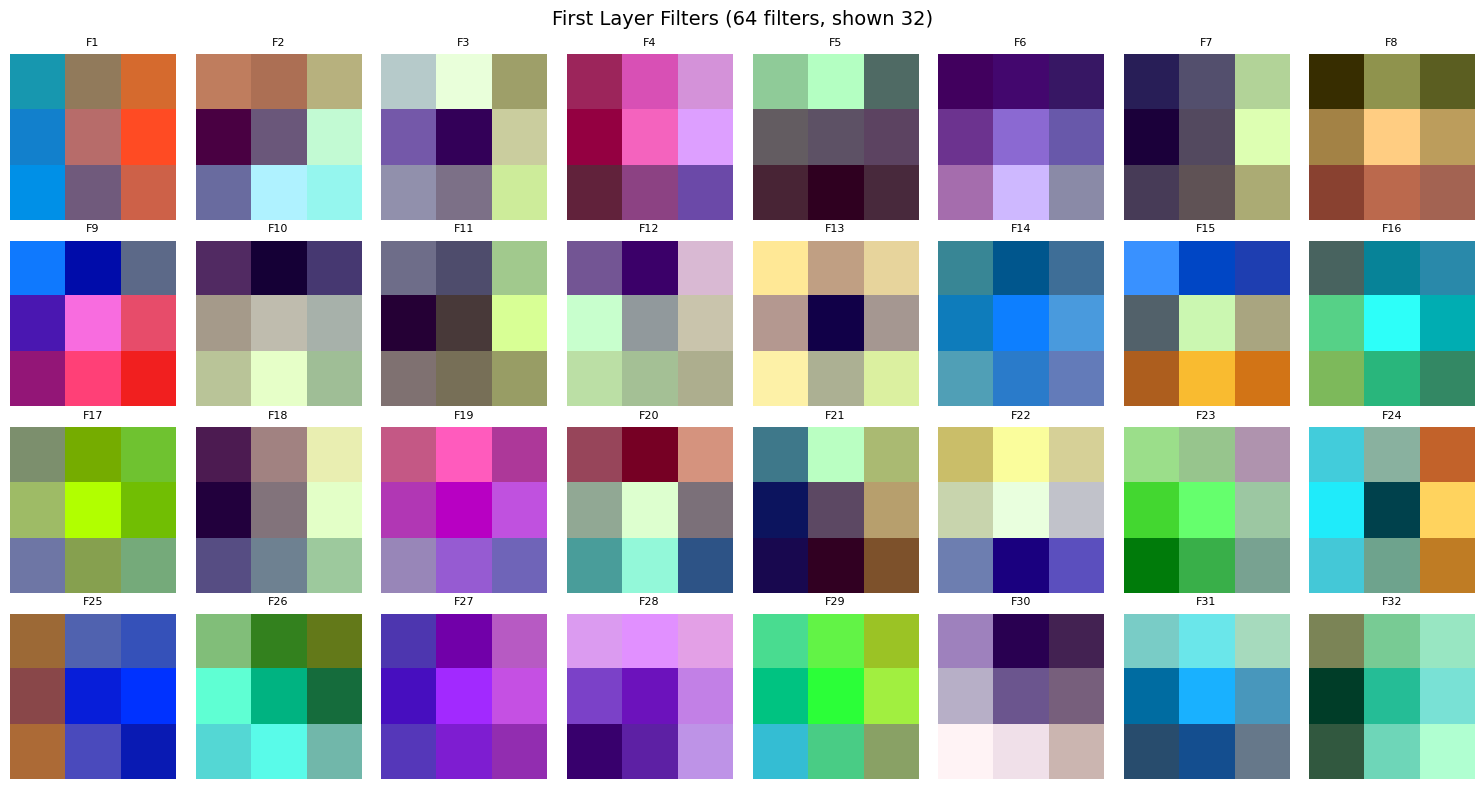

In [ ]:
first_conv_weights = vgg16.features[0].weight.data

fig, axes = plt.subplots(4, 8, figsize=(15, 8))
fig.suptitle("First Layer Filters (64 filters, shown 32)", fontsize=14)

for i in range(32):
    row = i // 8
    col = i % 8
    filter_weights = first_conv_weights[i].cpu().numpy()
    filter_weights = (filter_weights - filter_weights.min()) / (filter_weights.max() - filter_weights.min())
    filter_weights = np.transpose(filter_weights, (1, 2, 0))

    axes[row, col].imshow(filter_weights)
    axes[row, col].axis('off')
    axes[row, col].set_title(f'F{i+1}', fontsize=8)

plt.tight_layout()
plt.show()